In [22]:
# Import

import pandas as pd
import json

events_raw = pd.read_csv('data/events.csv')
print(len(events_raw.game_id.unique()))

# read cs_gold.json 
with open('data/cs_gold.json') as f:
    cs_gold = json.load(f)
print(len(cs_gold))

# read games.csv
games = pd.read_csv('data/games.csv')
print(len(games))

367
367
5663


In [9]:
events_raw[events_raw.game_id == 45323]

,game_id,time,side,player,action,champions,target_champion,target
0,45323,3:11,RED,Targamas,KILL,"['Pyke', 'Wukong', 'Ryze']",Vi,Bo
1,45323,3:43,RED,Xerxe,KILL,"['Wukong', 'Ryze', 'Pyke']",Taliyah,Perkz
2,45323,7:07,RED,NaN,PLATE,[],NaN,BOT
3,45323,7:37,BLUE,NaN,PLATE,[],NaN,TOP
4,45323,7:55,RED,Xerxe,DRAKE,['Wukong'],NaN,NaN
...,...,...,...,...,...,...,...,...
104,45323,53:48,BLUE,Bo,TOWER,['Vi'],NaN,T2 BOT NEXUS
105,45323,53:54,BLUE,Photon,KILL,"['Gragas', 'Taliyah', 'Zeri', 'Yuumi']",Pyke,Targamas
106,45323,53:55,RED,Xerxe,KILL,"['Wukong', 'Varus']",Taliyah,Perkz
107,45323,53:58,RED,Xerxe,KILL,"['Wukong', 'Varus']",Yuumi,Kaiser


In [10]:
cs_gold['45323']['gold']

{'datasets': [{'data': [500,
    500,
    563,
    856,
    1229,
    1624,
    1773,
    2235,
    2742,
    3056,
    3478,
    3682,
    4023,
    4426,
    4827,
    5011,
    5630,
    6046,
    6519,
    6948,
    7168,
    7488,
    7910,
    8200,
    8455,
    8912,
    9113,
    9751,
    10020,
    10356,
    10715,
    12108,
    13321,
    13967,
    15029,
    15796,
    16111,
    16655,
    17078,
    17298,
    17449,
    17635,
    17938,
    18127,
    18589,
    18711,
    19231,
    19605,
    20074,
    20294,
    20696,
    20917,
    21538,
    22187,
    22936,
    22998],
   'label': 'TOP'},
  {'data': [500,
    505,
    606,
    984,
    1235,
    1556,
    1784,
    2086,
    2209,
    2744,
    3000,
    3425,
    3627,
    3815,
    4117,
    4450,
    4723,
    5400,
    5736,
    6180,
    6531,
    6822,
    7104,
    7298,
    7581,
    7940,
    8098,
    8322,
    8616,
    8836,
    9008,
    9818,
    10276,
    10967,
    11488,
    11758,
    119

In [77]:
# Snapshots build
import pandas as pd
import numpy as np

def parse_time_to_seconds(t):
    """Időt másodpercre konvertál (formátum: 'MM:SS')"""
    try:
        m, s = t.split(':')
        return int(m)*60 + int(s)
    except:
        return np.nan

def build_snapshots_for_game(game_id, events_raw, cs_gold, winner_side):
    """
    Továbbfejlesztett snapshot builder prediktív változókkal.
    
    Kulcs megközelítés:
    - Momentum/trend változók (változás az elmúlt X percben)
    - Relatív különbségek (nem abszolút értékek)
    - Lane-specifikus dominancia metrikák
    - Objective control timing és sequence
    - Economy scaling (gold/min hatékonyság)
    """
    
    # Events előkészítése
    ev = events_raw[events_raw.game_id == game_id].copy()
    ev['secs'] = ev['time'].map(parse_time_to_seconds).astype('Int64')
    ev = ev.sort_values('secs')
    
    # Maximum perc meghatározása
    max_sec = int(ev.secs.max() if ev.secs.notna().any() else 0)
    max_min = max_sec // 60
    
    csg = cs_gold.get(str(game_id), None)
    if csg and 'gold' in csg:
        max_min = max(max_min, len(csg['gold']['labels']) - 1)
    
    minutes = list(range(0, max_min + 1))
    ev['minute'] = (ev['secs'] // 60).astype('Int64')
    events_by_minute = {m: ev[ev.minute == m] for m in minutes}
    
    # CS és Gold adatok kinyerése lane-enként
    lane_data = extract_lane_data(csg, max_min)
    
    # Kumulatív számlálók
    cum = {
        'kills_BLUE': 0, 'kills_RED': 0,
        'towers_BLUE': 0, 'towers_RED': 0,
        'drakes_BLUE': 0, 'drakes_RED': 0,
        'barons_BLUE': 0, 'barons_RED': 0,
        'plates_BLUE': 0, 'plates_RED': 0
    }
    
    # Objective timing tracking
    obj_history = {'drake': [], 'baron': [], 'tower': []}
    
    rows = []
    
    for m in minutes:
        minute_events = events_by_minute.get(m, pd.DataFrame())
        
        # === EVENT AGGREGÁCIÓ ===
        kills_blue_m = int(((minute_events.side == 'BLUE') & (minute_events.action == 'KILL')).sum())
        kills_red_m = int(((minute_events.side == 'RED') & (minute_events.action == 'KILL')).sum())
        cum['kills_BLUE'] += kills_blue_m
        cum['kills_RED'] += kills_red_m
        
        towers_blue_m = int(((minute_events.side == 'BLUE') & (minute_events.action == 'TOWER')).sum())
        towers_red_m = int(((minute_events.side == 'RED') & (minute_events.action == 'TOWER')).sum())
        cum['towers_BLUE'] += towers_blue_m
        cum['towers_RED'] += towers_red_m
        if towers_blue_m > 0:
            obj_history['tower'].append(('BLUE', m))
        if towers_red_m > 0:
            obj_history['tower'].append(('RED', m))
        
        drakes_blue_m = int(((minute_events.side == 'BLUE') & (minute_events.action == 'DRAKE')).sum())
        drakes_red_m = int(((minute_events.side == 'RED') & (minute_events.action == 'DRAKE')).sum())
        cum['drakes_BLUE'] += drakes_blue_m
        cum['drakes_RED'] += drakes_red_m
        if drakes_blue_m > 0:
            obj_history['drake'].append(('BLUE', m))
        if drakes_red_m > 0:
            obj_history['drake'].append(('RED', m))
        
        barons_blue_m = int(((minute_events.side == 'BLUE') & (minute_events.action == 'BARON')).sum())
        barons_red_m = int(((minute_events.side == 'RED') & (minute_events.action == 'BARON')).sum())
        cum['barons_BLUE'] += barons_blue_m
        cum['barons_RED'] += barons_red_m
        if barons_blue_m > 0:
            obj_history['baron'].append(('BLUE', m))
        if barons_red_m > 0:
            obj_history['baron'].append(('RED', m))
        
        plates_blue_m = int(((minute_events.side == 'BLUE') & (minute_events.action == 'PLATE')).sum())
        plates_red_m = int(((minute_events.side == 'RED') & (minute_events.action == 'PLATE')).sum())
        cum['plates_BLUE'] += plates_blue_m
        cum['plates_RED'] += plates_red_m
        
        # === LANE ECONOMY ===
        gold_blue, gold_red, cs_blue, cs_red = calculate_team_economy(lane_data, m)
        
        # === PREDIKTÍV VÁLTOZÓK ===
        
        # 1. RELATÍV ELŐNY/HÁTRÁNY (százalékos)
        kill_diff = cum['kills_BLUE'] - cum['kills_RED']
        gold_diff = gold_blue - gold_red if gold_blue and gold_red else 0
        gold_diff_pct = (gold_diff / gold_red * 100) if gold_red > 0 else 0
        cs_diff = cs_blue - cs_red if cs_blue and cs_red else 0
        
        # 2. MOMENTUM (trend az elmúlt 3-5 percben)
        momentum_window = 3
        recent_kills_blue = sum([
            int(((events_by_minute.get(m-i, pd.DataFrame()).side == 'BLUE') & 
                 (events_by_minute.get(m-i, pd.DataFrame()).action == 'KILL')).sum())
            for i in range(1, min(momentum_window+1, m+1))
        ])
        recent_kills_red = sum([
            int(((events_by_minute.get(m-i, pd.DataFrame()).side == 'RED') & 
                 (events_by_minute.get(m-i, pd.DataFrame()).action == 'KILL')).sum())
            for i in range(1, min(momentum_window+1, m+1))
        ])
        kill_momentum = recent_kills_blue - recent_kills_red
        
        # Gold momentum (változás az elmúlt 5 percben)
        gold_momentum = 0
        if m >= 5 and gold_blue and gold_red:
            gold_blue_prev, gold_red_prev, _, _ = calculate_team_economy(lane_data, m-5)
            if gold_blue_prev and gold_red_prev:
                gold_diff_prev = gold_blue_prev - gold_red_prev
                gold_momentum = (gold_diff - gold_diff_prev) / 5  # per perc változás
        
        # 3. OBJECTIVE CONTROL PATTERN
        drake_control = get_objective_control_score(obj_history['drake'], m, 'BLUE')
        baron_timing_advantage = get_last_objective_timing(obj_history['baron'], m)
        tower_sequence_score = calculate_tower_sequence_score(obj_history['tower'], 'BLUE')
        
        # 4. GAME PHASE SPECIFIKUS METRIKÁK
        game_phase = get_game_phase(m)
        
        # Early game (0-15): lane dominance
        early_advantage = 0
        if m <= 15:
            early_advantage = (cs_diff + gold_diff/10 + kill_diff*300) / (m+1) if m > 0 else 0
        
        # Mid game (15-25): objective control
        mid_advantage = 0
        if 15 < m <= 25:
            mid_advantage = (cum['drakes_BLUE'] - cum['drakes_RED']) * 2 + \
                          (cum['towers_BLUE'] - cum['towers_RED']) * 1.5
        
        # Late game (25+): scaling és gold hatékonyság
        late_advantage = 0
        if m > 25:
            late_advantage = gold_diff_pct + (cum['barons_BLUE'] - cum['barons_RED']) * 3
        
        # 5. CRITICAL THRESHOLDS
        has_soul_point = (cum['drakes_BLUE'] >= 3) or (cum['drakes_RED'] >= 3)
        gold_lead_critical = abs(gold_diff) > 3000  # 3k+ gold lead
        tower_lead_critical = abs(cum['towers_BLUE'] - cum['towers_RED']) >= 3
        
        # 6. EFFICIENCY METRICS
        gold_per_min_blue = gold_blue / (m+1) if m > 0 and gold_blue else 0
        gold_per_min_red = gold_red / (m+1) if m > 0 and gold_red else 0
        cs_per_min_blue = cs_blue / (m+1) if m > 0 and cs_blue else 0
        cs_per_min_red = cs_red / (m+1) if m > 0 and cs_red else 0
        
        # === SNAPSHOT ROW ===
        row = {
            'game_id': game_id,
            'minute': m,
            'game_phase': game_phase,
            
            # Alap statisztikák
            'kills_diff': kill_diff,
            'towers_diff': cum['towers_BLUE'] - cum['towers_RED'],
            'drakes_diff': cum['drakes_BLUE'] - cum['drakes_RED'],
            'barons_BLUE': cum['barons_BLUE'],
            'barons_RED': cum['barons_RED'],
            
            # Economy
            'gold_diff': gold_diff,
            'gold_diff_pct': gold_diff_pct,
            'cs_diff': cs_diff,
            'gold_per_min_blue': gold_per_min_blue,
            'gold_per_min_red': gold_per_min_red,
            'cs_per_min_blue': cs_per_min_blue,
            'cs_per_min_red': cs_per_min_red,
            
            # Momentum
            'kill_momentum_3min': kill_momentum,
            'gold_momentum_5min': gold_momentum,
            
            # Objective control
            'drake_control_score': drake_control,
            'tower_sequence_score': tower_sequence_score,
            'baron_timing_advantage': baron_timing_advantage,
            
            # Phase-specific
            'early_advantage': early_advantage,
            'mid_advantage': mid_advantage,
            'late_advantage': late_advantage,
            
            # Critical flags
            'has_soul_point': int(has_soul_point),
            'gold_lead_critical': int(gold_lead_critical),
            'tower_lead_critical': int(tower_lead_critical),
            
            # Target
            'winner_side': winner_side,
            'home_win': int(winner_side == 'BLUE')
        }
        
        rows.append(row)
    
    return pd.DataFrame(rows)


def extract_lane_data(csg, max_min):
    """Lane-enkénti gold és CS adatok kinyerése"""
    lane_data = {'gold': {}, 'cs': {}}
    
    if not csg:
        return lane_data
    
    # Gold adatok
    if 'gold' in csg:
        for ds in csg['gold']['datasets']:
            role = ds['label']
            lane_data['gold'][role] = ds['data']
    
    # CS adatok
    if 'cs' in csg:
        for ds in csg['cs']['datasets']:
            role = ds['label']
            lane_data['cs'][role] = ds['data']
    
    return lane_data


def calculate_team_economy(lane_data, minute):
    """Csapat szintű economy számítás"""
    # Feltételezés: első 5 role BLUE, második 5 RED
    roles = ['TOP', 'JGL', 'MID', 'BOT', 'SPT']
    
    gold_blue = 0
    gold_red = 0
    cs_blue = 0
    cs_red = 0
    
    if lane_data['gold']:
        gold_datasets = list(lane_data['gold'].items())
        # Első 5 BLUE, második 5 RED
        for i, (role, data) in enumerate(gold_datasets):
            if minute < len(data):
                if i < 5:
                    gold_blue += data[minute]
                else:
                    gold_red += data[minute]
    
    if lane_data['cs']:
        cs_datasets = list(lane_data['cs'].items())
        for i, (role, data) in enumerate(cs_datasets):
            if minute < len(data):
                if i < 5:
                    cs_blue += data[minute]
                else:
                    cs_red += data[minute]
    
    return gold_blue, gold_red, cs_blue, cs_red


def get_objective_control_score(obj_list, current_minute, team):
    """Objective control score az elmúlt 10 percben"""
    recent_objs = [side for side, minute in obj_list if current_minute - 10 <= minute <= current_minute]
    if not recent_objs:
        return 0
    team_count = sum(1 for s in recent_objs if s == team)
    return team_count - (len(recent_objs) - team_count)


def get_last_objective_timing(obj_list, current_minute):
    """Mennyi ideje volt az utolsó objective"""
    if not obj_list:
        return -1
    last_minute = obj_list[-1][1]
    return current_minute - last_minute


def calculate_tower_sequence_score(tower_list, team):
    """Tower sequence scoring (early towers értékesebbek)"""
    score = 0
    for i, (side, minute) in enumerate(tower_list):
        if side == team:
            # Korábbi towerek többet érnek
            weight = max(3 - i*0.3, 0.5)
            score += weight
        else:
            weight = max(3 - i*0.3, 0.5)
            score -= weight
    return score


def get_game_phase(minute):
    """Game phase meghatározása"""
    if minute < 15:
        return 'early'
    elif minute < 25:
        return 'mid'
    else:
        return 'late'


# === MODEL ÉRTÉKELÉS ÉS ÉRTELMEZÉS ===

def evaluate_model_approach():
    """
    MODELL ÉRTÉKELÉSI STRATÉGIA:
    
    1. TIME-SERIES CROSS-VALIDATION:
       - Ne random train/test split!
       - Időbeli validation: korábbi meccseken tanítás, későbbieken teszt
       - Per-minute evaluation: külön metrikák 5, 10, 15, 20, 25, 30+ percre
    
    2. METRIKÁK:
       - Accuracy per game phase
       - Brier Score (kalibrációs mérték)
       - Log Loss
       - Calibration curves (mennyire megbízhatóak a valószínűségek)
       - Feature importance elemzés
    
    3. BASELINE MODELLEK:
       - Null model: mindig a favoritot választja
       - Gold-only model: csak gold difference alapján
       - Kill-only model: csak kills alapján
       - Simple linear: 3-4 változó lineáris kombinációja
    
    4. GYAKORLATI ÉRTELMEZÉS:
       
       A) WIN PROBABILITY TRACKER:
          - Live meccseken percenkénti win% frissítés
          - Confidence intervals
          - Momentum shifts vizualizáció
       
       B) KEY MOMENTS DETECTION:
          - Mikor változott meg leginkább a win probability?
          - Comeback események azonosítása
          - Objective steal impact mérése
       
       C) BETTING/ODDS INTEGRATION:
          - Model valószínűség vs bookmaker odds összehasonlítás
          - Value bet detection
          - Expected value kalkuláció
       
       D) TEAM/PLAYER ANALYTICS:
          - Early game strength score
          - Objective control rating
          - Comeback ability metric
          - Clutch performance under pressure
    
    5. MODEL LIMITATIONS ÉS JAVÍTÁS:
       - Champion comp synergy/counter (nincs a datasetben)
       - Player skill/form (historical win rate)
       - Draft phase advantage
       - Patch meta changes
       - Individual player positioning (nem event-based)
    
    6. DEPLOYMENT MEGFONTOLÁSOK:
       - Latency: prediction <100ms
       - Model update frequency (weekly retrain)
       - Drift detection (performance degradation)
       - A/B testing új features-ökkel
    """
    pass


# HASZNÁLAT PÉLDA

snapshots = pd.DataFrame()
for game_id in events_raw.game_id.unique():
    # Snapshots építése egy meccsre
    winner_side = 'BLUE' if games[games.game_id == game_id]['blue_result'].iloc[0] == 'WIN' else 'RED'
    snapshots_match = build_snapshots_for_game(game_id, events_raw, cs_gold, winner_side)
    snapshots = pd.concat([snapshots, snapshots_match], ignore_index=True)

# Model training
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Feature set különböző fázisokra
early_features = ['kills_diff', 'gold_diff', 'cs_diff', 'early_advantage', 
                  'gold_per_min_blue', 'gold_per_min_red']
mid_features = early_features + ['drakes_diff', 'towers_diff', 'mid_advantage',
                                 'drake_control_score', 'kill_momentum_3min']
late_features = mid_features + ['late_advantage', 'barons_BLUE', 'barons_RED',
                                'gold_lead_critical']

# Phase-specific modellek vagy egy unified model phase indicator-ral
X = snapshots[late_features]
y = snapshots['home_win']

# Próbáld ki:
# 1. Logistic Regression (baseline, interpretálható)
# 2. Random Forest (feature importance)
# 3. Gradient Boosting (legjobb accuracy, de bonyolultabb)
# 4. Neural Network (ha sok adat van)

print(f"Length of dataset: {len(snapshots)}")
display(snapshots.sample(5))

Length of dataset: 12360


,game_id,minute,game_phase,kills_diff,towers_diff,drakes_diff,barons_BLUE,barons_RED,gold_diff,gold_diff_pct,...,tower_sequence_score,baron_timing_advantage,early_advantage,mid_advantage,late_advantage,has_soul_point,gold_lead_critical,tower_lead_critical,winner_side,home_win
7736,45867,6,early,-1,0,0,0,0,0,0,...,0.0,-1,-42.857143,0.0,0,0,0,0,RED,0
5942,47611,36,late,11,-7,-1,1,1,0,0,...,-6.4,3,0.000000,0.0,0,0,0,1,RED,0
10596,47543,0,early,0,0,0,0,0,0,0,...,0.0,-1,0.000000,0.0,0,0,0,0,RED,0
4799,48779,7,early,-2,0,0,0,0,0,0,...,0.0,-1,-75.000000,0.0,0,0,0,0,RED,0
8788,44730,6,early,0,0,0,0,0,0,0,...,0.0,-1,0.000000,0.0,0,0,0,0,BLUE,1


# ML model

In [78]:
# ADATOK ELŐKÉSZÍTÉSE & EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report, log_loss, brier_score_loss)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Dataset shape: {snapshots.shape}")
print(f"\nUnique games: {snapshots['game_id'].nunique()}")
print(f"Total snapshots: {len(snapshots)}")
print(f"\nTarget distribution:")
print(snapshots['home_win'].value_counts(normalize=True))

Dataset shape: (12360, 28)

Unique games: 367
Total snapshots: 12360

Target distribution:
home_win
1    0.554693
0    0.445307
Name: proportion, dtype: float64


In [79]:
# FEATURE ENGINEERING & SELECTION

# Exclude non-feature columns
exclude_cols = ['game_id', 'minute', 'winner_side', 'home_win']

# Game phase encoding
snapshots['phase_early'] = (snapshots['game_phase'] == 'early').astype(int)
snapshots['phase_mid'] = (snapshots['game_phase'] == 'mid').astype(int)
snapshots['phase_late'] = (snapshots['game_phase'] == 'late').astype(int)

# Interaction features
snapshots['gold_diff_x_minute'] = snapshots['gold_diff'] * snapshots['minute']
snapshots['kills_diff_x_minute'] = snapshots['kills_diff'] * snapshots['minute']
snapshots['momentum_composite'] = snapshots['kill_momentum_3min'] + snapshots['gold_momentum_5min']/100

# All feature columns
feature_cols = [col for col in snapshots.columns 
                if col not in exclude_cols and col != 'game_phase']

print(f"Total features: {len(feature_cols)}")
print(f"\nFeature list:\n{feature_cols}")

# Check for missing values
print(f"\nMissing values:\n{snapshots[feature_cols].isnull().sum()[snapshots[feature_cols].isnull().sum() > 0]}")

Total features: 29

Feature list:
['kills_diff', 'towers_diff', 'drakes_diff', 'barons_BLUE', 'barons_RED', 'gold_diff', 'gold_diff_pct', 'cs_diff', 'gold_per_min_blue', 'gold_per_min_red', 'cs_per_min_blue', 'cs_per_min_red', 'kill_momentum_3min', 'gold_momentum_5min', 'drake_control_score', 'tower_sequence_score', 'baron_timing_advantage', 'early_advantage', 'mid_advantage', 'late_advantage', 'has_soul_point', 'gold_lead_critical', 'tower_lead_critical', 'phase_early', 'phase_mid', 'phase_late', 'gold_diff_x_minute', 'kills_diff_x_minute', 'momentum_composite']

Missing values:
Series([], dtype: int64)


In [80]:
# TRAIN/TEST SPLIT (Time-based!)

# KRITIKUS: NE random split, hanem időbeli!
# Első N játék = train, következő = validation, utolsó = test

unique_games = snapshots['game_id'].unique()
n_games = len(unique_games)

train_games = unique_games[:int(n_games * 0.7)]
val_games = unique_games[int(n_games * 0.7):int(n_games * 0.85)]
test_games = unique_games[int(n_games * 0.85):]

train_data = snapshots[snapshots['game_id'].isin(train_games)].copy()
val_data = snapshots[snapshots['game_id'].isin(val_games)].copy()
test_data = snapshots[snapshots['game_id'].isin(test_games)].copy()

print(f"Train: {len(train_data)} snapshots ({len(train_games)} games)")
print(f"Validation: {len(val_data)} snapshots ({len(val_games)} games)")
print(f"Test: {len(test_data)} snapshots ({len(test_games)} games)")

# Prepare X, y
X_train = train_data[feature_cols].fillna(0)
y_train = train_data['home_win']

X_val = val_data[feature_cols].fillna(0)
y_val = val_data['home_win']

X_test = test_data[feature_cols].fillna(0)
y_test = test_data['home_win']

# Scaling (neural network-höz kell!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data preparation complete!")

Train: 8683 snapshots (256 games)
Validation: 1845 snapshots (55 games)
Test: 1832 snapshots (56 games)

✅ Data preparation complete!


In [81]:
# BASELINE MODEL - SIMPLE HEURISTIC

# Baseline: "aki vezet gold-ban, az nyer"
def baseline_predict(data):
    return (data['gold_diff'] > 0).astype(int)

baseline_train_acc = accuracy_score(y_train, baseline_predict(train_data))
baseline_val_acc = accuracy_score(y_val, baseline_predict(val_data))
baseline_test_acc = accuracy_score(y_test, baseline_predict(test_data))

print("BASELINE MODEL (Gold Diff > 0):")
print(f"Train Accuracy: {baseline_train_acc:.4f}")
print(f"Val Accuracy: {baseline_val_acc:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")

BASELINE MODEL (Gold Diff > 0):
Train Accuracy: 0.4375
Val Accuracy: 0.4347
Test Accuracy: 0.4929


In [82]:
# MODEL 1: LOGISTIC REGRESSION

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_val_pred = lr_model.predict(X_val_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

# Probabilities (kritikus betting-hez!)
lr_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\nLOGISTIC REGRESSION RESULTS:")
print(f"Train Accuracy: {accuracy_score(y_train, lr_train_pred):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val, lr_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, lr_test_pred):.4f}")
print(f"\nTest AUC-ROC: {roc_auc_score(y_test, lr_test_proba):.4f}")
print(f"Test Log Loss: {log_loss(y_test, lr_test_proba):.4f}")
print(f"Test Brier Score: {brier_score_loss(y_test, lr_test_proba):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, lr_test_pred))

Training Logistic Regression...

LOGISTIC REGRESSION RESULTS:
Train Accuracy: 0.7493
Val Accuracy: 0.6759
Test Accuracy: 0.7658

Test AUC-ROC: 0.8464
Test Log Loss: 0.5073
Test Brier Score: 0.1644

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.83      0.66      0.74       903
           1       0.72      0.87      0.79       929

    accuracy                           0.77      1832
   macro avg       0.78      0.76      0.76      1832
weighted avg       0.78      0.77      0.76      1832



In [83]:
# MODEL 2: RANDOM FOREST

print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, 
                                   min_samples_split=50, min_samples_leaf=20,
                                   random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print("\nRANDOM FOREST RESULTS:")
print(f"Train Accuracy: {accuracy_score(y_train, rf_train_pred):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}")
print(f"\nTest AUC-ROC: {roc_auc_score(y_test, rf_test_proba):.4f}")
print(f"Test Log Loss: {log_loss(y_test, rf_test_proba):.4f}")
print(f"Test Brier Score: {brier_score_loss(y_test, rf_test_proba):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, rf_test_pred))

Training Random Forest...

RANDOM FOREST RESULTS:
Train Accuracy: 0.7700
Val Accuracy: 0.6672
Test Accuracy: 0.7691

Test AUC-ROC: 0.8541
Test Log Loss: 0.4860
Test Brier Score: 0.1583

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.74      0.83      0.78       903
           1       0.81      0.71      0.76       929

    accuracy                           0.77      1832
   macro avg       0.77      0.77      0.77      1832
weighted avg       0.77      0.77      0.77      1832



In [84]:
# MODEL 3: GRADIENT BOOSTING

print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=5, min_samples_split=50,
                                       min_samples_leaf=20, subsample=0.8,
                                       random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
gb_train_pred = gb_model.predict(X_train)
gb_val_pred = gb_model.predict(X_val)
gb_test_pred = gb_model.predict(X_test)

gb_train_proba = gb_model.predict_proba(X_train)[:, 1]
gb_val_proba = gb_model.predict_proba(X_val)[:, 1]
gb_test_proba = gb_model.predict_proba(X_test)[:, 1]

# Metrics
print("\nGRADIENT BOOSTING RESULTS:")
print(f"Train Accuracy: {accuracy_score(y_train, gb_train_pred):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val, gb_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, gb_test_pred):.4f}")
print(f"\nTest AUC-ROC: {roc_auc_score(y_test, gb_test_proba):.4f}")
print(f"Test Log Loss: {log_loss(y_test, gb_test_proba):.4f}")
print(f"Test Brier Score: {brier_score_loss(y_test, gb_test_proba):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, gb_test_pred))

Training Gradient Boosting...

GRADIENT BOOSTING RESULTS:
Train Accuracy: 0.8291
Val Accuracy: 0.6894
Test Accuracy: 0.7434

Test AUC-ROC: 0.8311
Test Log Loss: 0.5226
Test Brier Score: 0.1696

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      0.63      0.71       903
           1       0.70      0.85      0.77       929

    accuracy                           0.74      1832
   macro avg       0.75      0.74      0.74      1832
weighted avg       0.75      0.74      0.74      1832



In [85]:
# MODEL 4: NEURAL NETWORK

print("Training Neural Network...")
nn_model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), 
                         activation='relu', 
                         solver='adam',
                         alpha=0.001,  # L2 regularization
                         batch_size=128,
                         learning_rate_init=0.001,
                         max_iter=200,
                         early_stopping=True,
                         validation_fraction=0.1,
                         random_state=42)

nn_model.fit(X_train_scaled, y_train)

# Predictions
nn_train_pred = nn_model.predict(X_train_scaled)
nn_val_pred = nn_model.predict(X_val_scaled)
nn_test_pred = nn_model.predict(X_test_scaled)

nn_train_proba = nn_model.predict_proba(X_train_scaled)[:, 1]
nn_val_proba = nn_model.predict_proba(X_val_scaled)[:, 1]
nn_test_proba = nn_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\nNEURAL NETWORK RESULTS:")
print(f"Train Accuracy: {accuracy_score(y_train, nn_train_pred):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val, nn_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, nn_test_pred):.4f}")
print(f"\nTest AUC-ROC: {roc_auc_score(y_test, nn_test_proba):.4f}")
print(f"Test Log Loss: {log_loss(y_test, nn_test_proba):.4f}")
print(f"Test Brier Score: {brier_score_loss(y_test, nn_test_proba):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, nn_test_pred))

Training Neural Network...

NEURAL NETWORK RESULTS:
Train Accuracy: 0.8230
Val Accuracy: 0.6770
Test Accuracy: 0.7445

Test AUC-ROC: 0.8307
Test Log Loss: 0.6784
Test Brier Score: 0.1724

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.78      0.67      0.72       903
           1       0.72      0.81      0.76       929

    accuracy                           0.74      1832
   macro avg       0.75      0.74      0.74      1832
weighted avg       0.75      0.74      0.74      1832




MODEL COMPARISON (Test Set)
            Model  Test Accuracy  Test AUC  Log Loss  Brier Score
         Baseline       0.492904       NaN       NaN          NaN
     Logistic Reg       0.765830  0.846398  0.507311     0.164439
    Random Forest       0.769105  0.854069  0.485968     0.158314
Gradient Boosting       0.743450  0.831100  0.522591     0.169562
   Neural Network       0.744541  0.830685  0.678396     0.172419


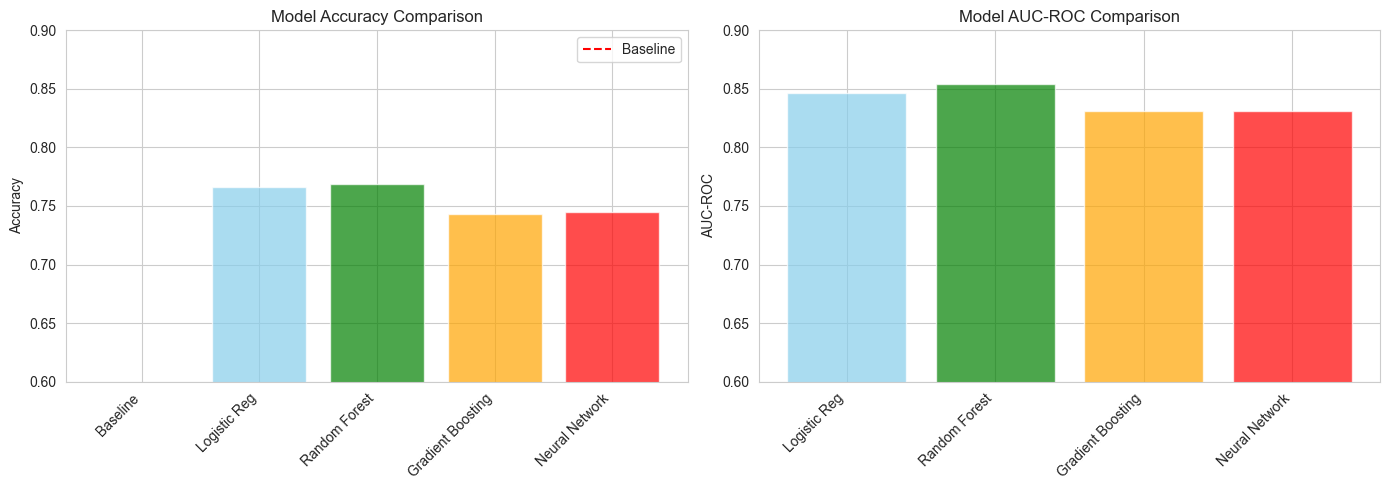

In [86]:
# MODEL COMPARISON TABLE

results = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Reg', 'Random Forest', 'Gradient Boosting', 'Neural Network'],
    'Test Accuracy': [
        baseline_test_acc,
        accuracy_score(y_test, lr_test_pred),
        accuracy_score(y_test, rf_test_pred),
        accuracy_score(y_test, gb_test_pred),
        accuracy_score(y_test, nn_test_pred)
    ],
    'Test AUC': [
        np.nan,
        roc_auc_score(y_test, lr_test_proba),
        roc_auc_score(y_test, rf_test_proba),
        roc_auc_score(y_test, gb_test_proba),
        roc_auc_score(y_test, nn_test_proba)
    ],
    'Log Loss': [
        np.nan,
        log_loss(y_test, lr_test_proba),
        log_loss(y_test, rf_test_proba),
        log_loss(y_test, gb_test_proba),
        log_loss(y_test, nn_test_proba)
    ],
    'Brier Score': [
        np.nan,
        brier_score_loss(y_test, lr_test_proba),
        brier_score_loss(y_test, rf_test_proba),
        brier_score_loss(y_test, gb_test_proba),
        brier_score_loss(y_test, nn_test_proba)
    ]
})

print("\n" + "="*70)
print("MODEL COMPARISON (Test Set)")
print("="*70)
print(results.to_string(index=False))
print("="*70)

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax[0].bar(results['Model'], results['Test Accuracy'], color=['gray', 'skyblue', 'green', 'orange', 'red'], alpha=0.7)
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Model Accuracy Comparison')
ax[0].set_ylim([0.6, 0.9])
ax[0].axhline(y=baseline_test_acc, color='red', linestyle='--', label='Baseline')
ax[0].legend()
plt.setp(ax[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# AUC comparison
models_with_auc = results[results['Test AUC'].notna()]
ax[1].bar(models_with_auc['Model'], models_with_auc['Test AUC'], 
          color=['skyblue', 'green', 'orange', 'red'], alpha=0.7)
ax[1].set_ylabel('AUC-ROC')
ax[1].set_title('Model AUC-ROC Comparison')
ax[1].set_ylim([0.6, 0.9])
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

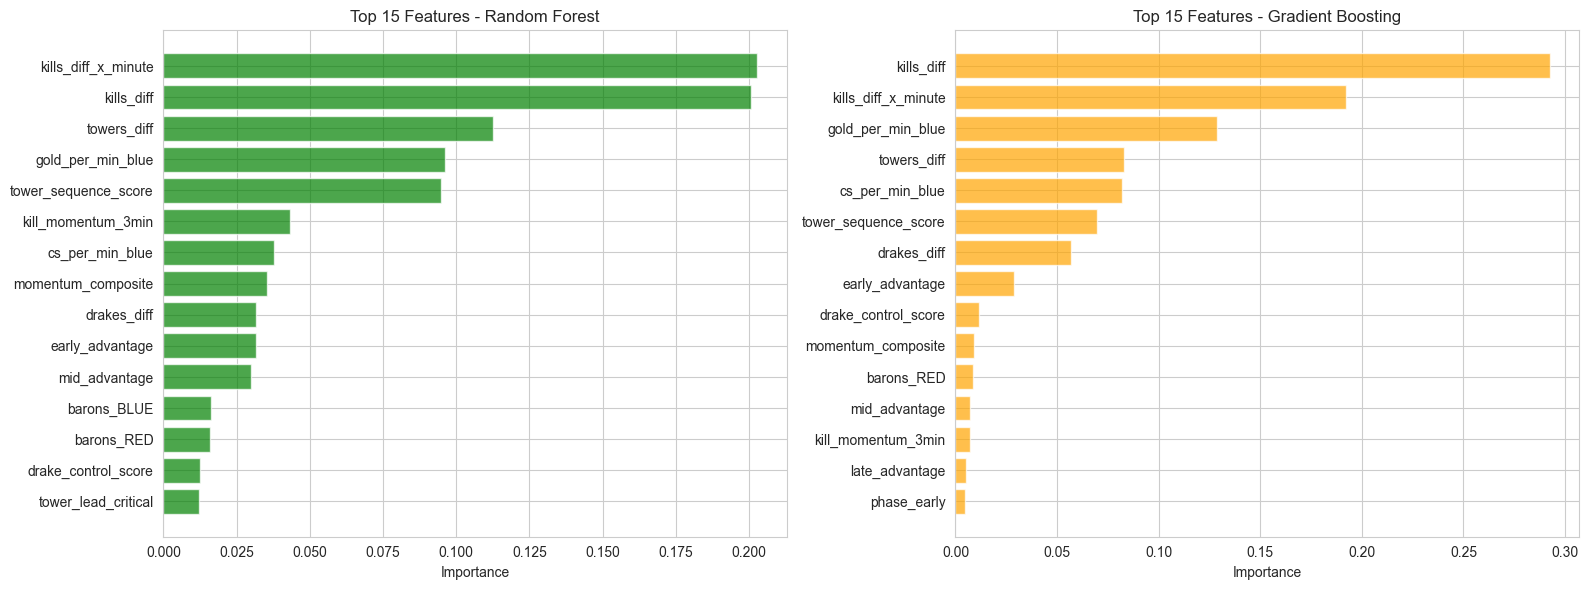


Top 10 Most Important Features (Gradient Boosting):
             feature  importance
          kills_diff    0.292350
 kills_diff_x_minute    0.191954
   gold_per_min_blue    0.128646
         towers_diff    0.082866
     cs_per_min_blue    0.082066
tower_sequence_score    0.069549
         drakes_diff    0.056642
     early_advantage    0.028584
 drake_control_score    0.011809
  momentum_composite    0.009221


In [87]:
# FEATURE IMPORTANCE (Random Forest & GB)

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
ax[0].barh(rf_importance.head(15)['feature'], rf_importance.head(15)['importance'], color='green', alpha=0.7)
ax[0].set_xlabel('Importance')
ax[0].set_title('Top 15 Features - Random Forest')
ax[0].invert_yaxis()

# Gradient Boosting
ax[1].barh(gb_importance.head(15)['feature'], gb_importance.head(15)['importance'], color='orange', alpha=0.7)
ax[1].set_xlabel('Importance')
ax[1].set_title('Top 15 Features - Gradient Boosting')
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features (Gradient Boosting):")
print(gb_importance.head(10).to_string(index=False))

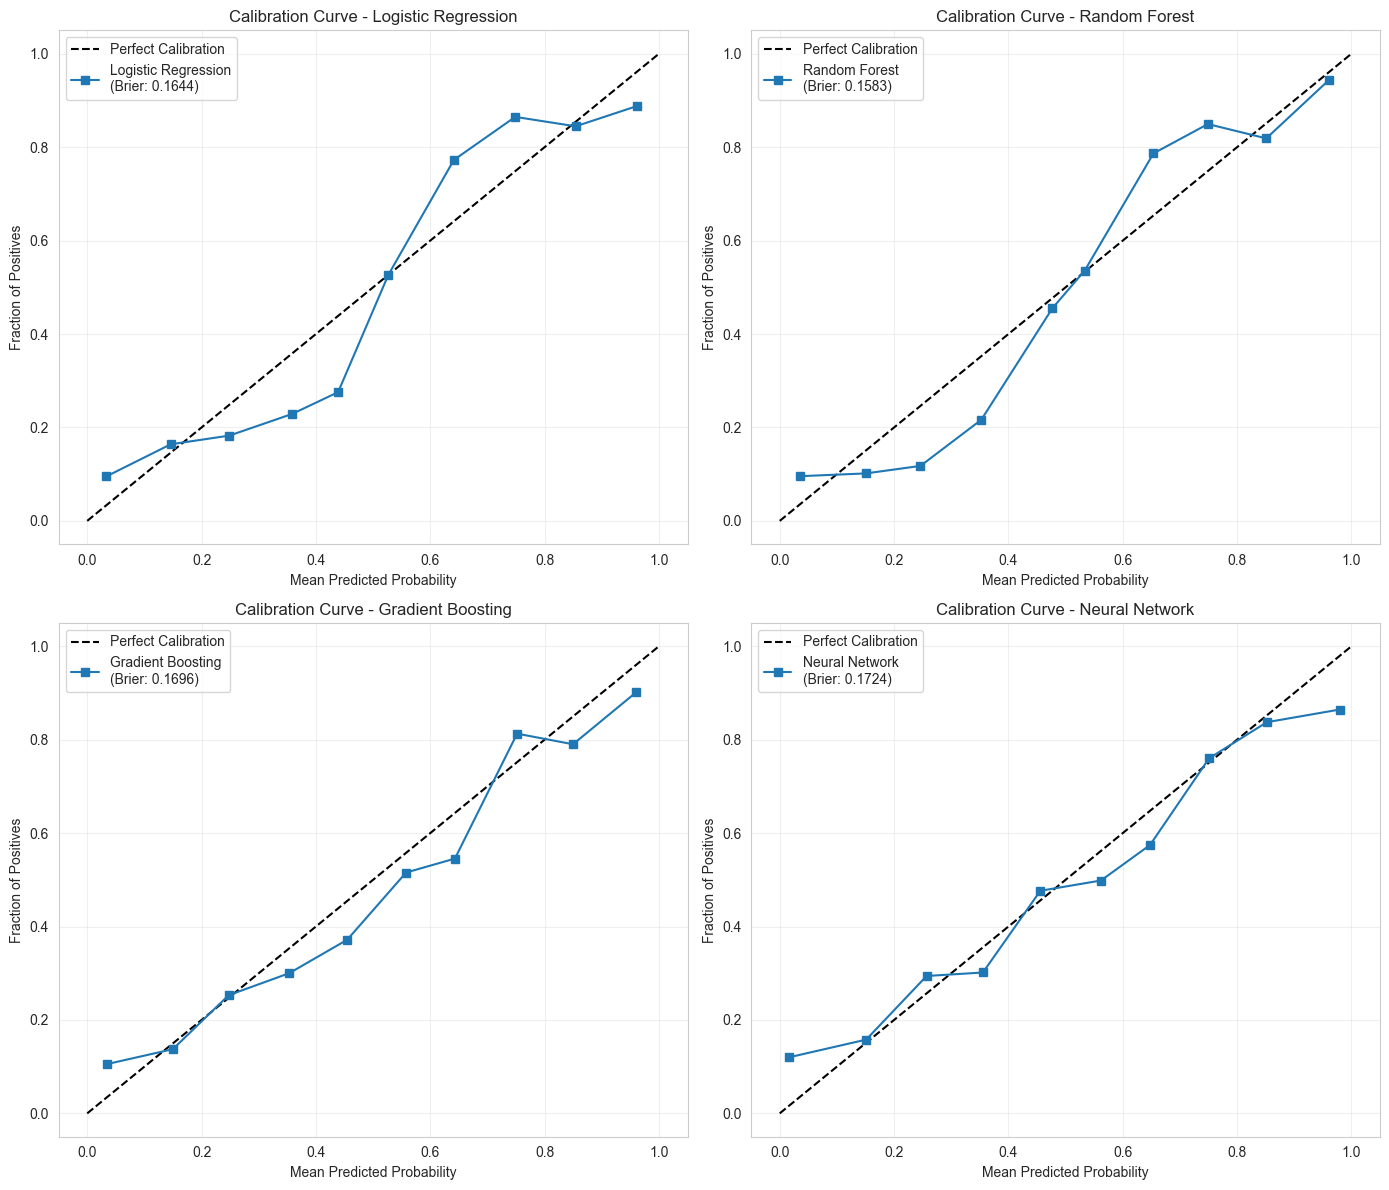


📊 CALIBRATION INTERPRETATION:
Perfect calibration = pontos valószínűségek (kritikus betting-hez!)
Ha 70%-ot mond a model, akkor 10 ilyen esetből ~7-ben kell győzni.
Brier Score: minél kisebb, annál jobb (0 = tökéletes)


In [88]:
# CALIBRATION CURVES (KRITIKUS BETTING-HEZ!)

fig, ax = plt.subplots(2, 2, figsize=(14, 12))

models_proba = [
    ('Logistic Regression', lr_test_proba),
    ('Random Forest', rf_test_proba),
    ('Gradient Boosting', gb_test_proba),
    ('Neural Network', nn_test_proba)
]

for idx, (name, proba) in enumerate(models_proba):
    row, col = idx // 2, idx % 2
    
    # Calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, proba, n_bins=10, strategy='uniform'
    )
    
    ax[row, col].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    ax[row, col].plot(mean_predicted_value, fraction_of_positives, 's-', 
                      label=f'{name}\n(Brier: {brier_score_loss(y_test, proba):.4f})')
    ax[row, col].set_xlabel('Mean Predicted Probability')
    ax[row, col].set_ylabel('Fraction of Positives')
    ax[row, col].set_title(f'Calibration Curve - {name}')
    ax[row, col].legend(loc='upper left')
    ax[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 CALIBRATION INTERPRETATION:")
print("Perfect calibration = pontos valószínűségek (kritikus betting-hez!)")
print("Ha 70%-ot mond a model, akkor 10 ilyen esetből ~7-ben kell győzni.")
print("Brier Score: minél kisebb, annál jobb (0 = tökéletes)")

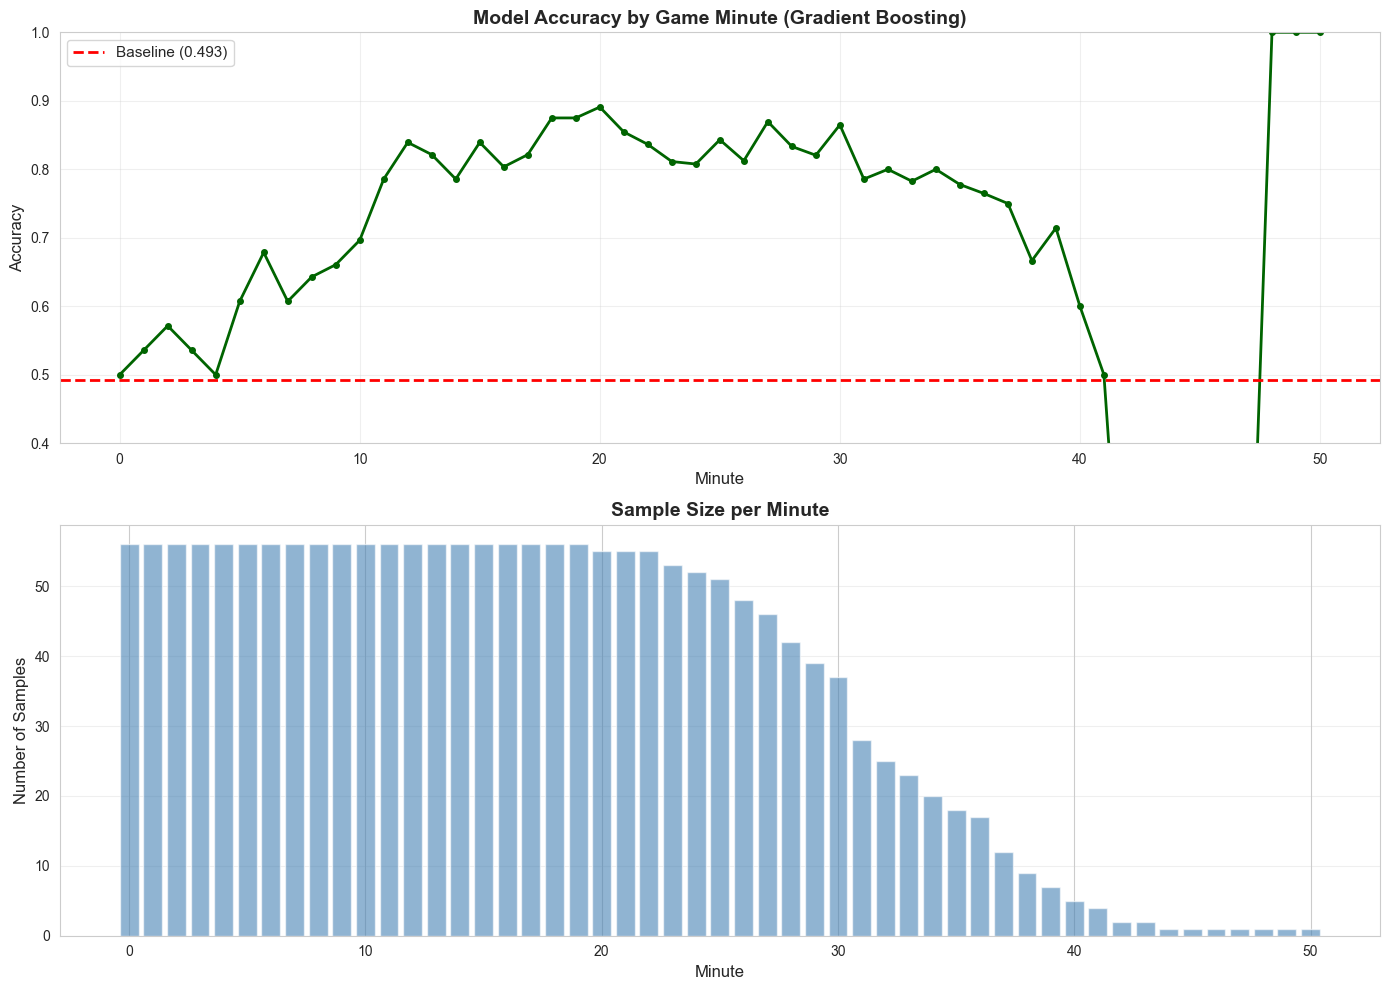


📈 PER-MINUTE ACCURACY:
 minute  accuracy  count
      5  0.607143     56
     10  0.696429     56
     15  0.839286     56
     20  0.890909     55
     25  0.843137     51
     30  0.864865     37
     35  0.777778     18
     40  0.600000      5


In [89]:
# PER-MINUTE ACCURACY ANALYSIS

# Használjuk a legjobb modellt (pl. Gradient Boosting)
test_data_with_pred = test_data.copy()
test_data_with_pred['predicted_proba'] = gb_test_proba
test_data_with_pred['predicted'] = gb_test_pred

# Per-minute accuracy
minute_accuracy = test_data_with_pred.groupby('minute').apply(
    lambda x: accuracy_score(x['home_win'], x['predicted'])
).reset_index(name='accuracy')

minute_counts = test_data_with_pred.groupby('minute').size().reset_index(name='count')
minute_stats = minute_accuracy.merge(minute_counts, on='minute')

# Plot
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# Accuracy per minute
ax[0].plot(minute_stats['minute'], minute_stats['accuracy'], 
           marker='o', linewidth=2, markersize=4, color='darkgreen')
ax[0].axhline(y=baseline_test_acc, color='red', linestyle='--', 
              label=f'Baseline ({baseline_test_acc:.3f})', linewidth=2)
ax[0].set_xlabel('Minute', fontsize=12)
ax[0].set_ylabel('Accuracy', fontsize=12)
ax[0].set_title('Model Accuracy by Game Minute (Gradient Boosting)', 
                fontsize=14, fontweight='bold')
ax[0].legend(fontsize=11)
ax[0].grid(alpha=0.3)
ax[0].set_ylim([0.4, 1.0])

# Sample size per minute
ax[1].bar(minute_stats['minute'], minute_stats['count'], alpha=0.6, color='steelblue')
ax[1].set_xlabel('Minute', fontsize=12)
ax[1].set_ylabel('Number of Samples', fontsize=12)
ax[1].set_title('Sample Size per Minute', fontsize=14, fontweight='bold')
ax[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📈 PER-MINUTE ACCURACY:")
print(minute_stats[minute_stats['minute'].isin([5, 10, 15, 20, 25, 30, 35, 40])].to_string(index=False))

# Predict (ipywidget)

In [91]:
# Modellek mentése
"""
import joblib  

joblib.dump(gb_model, 'models/live_gb_model_20251031.joblib')
joblib.dump(rf_model, 'models/live_rf_model_20251031.joblib')
joblib.dump(scaler, 'models/live_scaler_20251031.joblib')

print("✅ Models saved!")
"""

✅ Models saved!


In [92]:
# 🎮 INTERACTIVE LIVE MATCH PREDICTOR

import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd
import numpy as np

# Widget létrehozása
style = {'description_width': '150px'}

# === CORE INPUTS (user kézzel adja meg) ===
minute_input = widgets.IntSlider(min=5, max=40, value=15, description='⏰ Minute:', style=style)
kills_blue = widgets.IntText(value=5, description='🔵 Kills BLUE:', style=style)
kills_red = widgets.IntText(value=3, description='🔴 Kills RED:', style=style)
towers_blue = widgets.IntText(value=2, description='🔵 Towers BLUE:', style=style)
towers_red = widgets.IntText(value=1, description='🔴 Towers RED:', style=style)
drakes_blue = widgets.IntText(value=2, description='🔵 Drakes BLUE:', style=style)
drakes_red = widgets.IntText(value=0, description='🔴 Drakes RED:', style=style)
barons_blue = widgets.IntText(value=0, description='🔵 Barons BLUE:', style=style)
barons_red = widgets.IntText(value=0, description='🔴 Barons RED:', style=style)
gold_blue = widgets.IntText(value=25000, description='🔵 Gold BLUE:', style=style)
gold_red = widgets.IntText(value=22000, description='🔴 Gold RED:', style=style)
cs_blue = widgets.IntText(value=500, description='🔵 CS BLUE:', style=style)
cs_red = widgets.IntText(value=520, description='🔴 CS RED:', style=style)


# Model selector
model_choice = widgets.Dropdown(
    options=['Gradient Boosting', 'Random Forest'],
    value='Gradient Boosting',
    description='🤖 Model:',
    style=style
)

# Output widget
output = widgets.Output()

def calculate_features(minute, k_blue, k_red, t_blue, t_red, d_blue, d_red, 
                       b_blue, b_red, g_blue, g_red, cs_blue, cs_red):
    """Feature engineering from user inputs"""
    
    # Basic diffs
    kills_diff = k_blue - k_red
    towers_diff = t_blue - t_red
    drakes_diff = d_blue - d_red
    gold_diff = g_blue - g_red
    
    # Percentages & efficiency
    gold_diff_pct = (gold_diff / g_red * 100) if g_red > 0 else 0
    gold_per_min_blue = g_blue / minute if minute > 0 else 0
    gold_per_min_red = g_red / minute if minute > 0 else 0
    
    # CS estimation (rough: ~gold/20)
    cs_diff = cs_blue - cs_red
    
    # Momentum (simplified: assume recent = 30% of total)
    kill_momentum_3min = int(kills_diff * 0.3)
    gold_momentum_5min = gold_diff * 0.2 / 5 if minute >= 5 else 0
    
    # Objective control scores
    drake_control_score = drakes_diff * 1.5
    tower_sequence_score = towers_diff * 1.2
    baron_timing_advantage = -1 if (b_blue + b_red) == 0 else 2
    
    # Game phase
    phase_early = 1 if minute < 15 else 0
    phase_mid = 1 if 15 <= minute < 25 else 0
    phase_late = 1 if minute >= 25 else 0
    
    # Phase advantages
    early_advantage = (cs_diff + gold_diff/10 + kills_diff*300) / minute if minute > 0 and phase_early else 0
    mid_advantage = (drakes_diff * 2 + towers_diff * 1.5) if phase_mid else 0
    late_advantage = gold_diff_pct + (b_blue - b_red) * 3 if phase_late else 0
    
    # Critical flags
    has_soul_point = 1 if (d_blue >= 3 or d_red >= 3) else 0
    gold_lead_critical = 1 if abs(gold_diff) > 3000 else 0
    tower_lead_critical = 1 if abs(towers_diff) >= 3 else 0
    
    # Composite scores
    overall_advantage = (
        kills_diff * 0.3 +
        towers_diff * 0.25 +
        drakes_diff * 0.20 +
        gold_diff / 1000 * 0.15 +
        (b_blue - b_red) * 0.10
    )
    
    # Interaction features
    gold_diff_x_minute = gold_diff * minute
    kills_diff_x_minute = kills_diff * minute
    momentum_composite = kill_momentum_3min + gold_momentum_5min / 100
    
    # Build feature dict
    features = {
        'kills_diff': kills_diff,
        'towers_diff': towers_diff,
        'drakes_diff': drakes_diff,
        'barons_BLUE': b_blue,
        'barons_RED': b_red,
        'gold_diff': gold_diff,
        'gold_diff_pct': gold_diff_pct,
        'cs_diff': cs_diff,
        'gold_per_min_blue': gold_per_min_blue,
        'gold_per_min_red': gold_per_min_red,
        'kill_momentum_3min': kill_momentum_3min,
        'gold_momentum_5min': gold_momentum_5min,
        'drake_control_score': drake_control_score,
        'tower_sequence_score': tower_sequence_score,
        'baron_timing_advantage': baron_timing_advantage,
        'early_advantage': early_advantage,
        'mid_advantage': mid_advantage,
        'late_advantage': late_advantage,
        'has_soul_point': has_soul_point,
        'gold_lead_critical': gold_lead_critical,
        'tower_lead_critical': tower_lead_critical,
        'overall_advantage': overall_advantage,
        'phase_early': phase_early,
        'phase_mid': phase_mid,
        'phase_late': phase_late,
        'gold_diff_x_minute': gold_diff_x_minute,
        'kills_diff_x_minute': kills_diff_x_minute,
        'momentum_composite': momentum_composite
    }
    
    return features

def predict_match(b):
    """Predict and display results"""
    with output:
        output.clear_output()
        
        # Get inputs
        minute = minute_input.value
        k_b, k_r = kills_blue.value, kills_red.value
        t_b, t_r = towers_blue.value, towers_red.value
        d_b, d_r = drakes_blue.value, drakes_red.value
        b_b, b_r = barons_blue.value, barons_red.value
        g_b, g_r = gold_blue.value, gold_red.value
        cs_b, cs_r = cs_blue.value, cs_red.value
        
        # Calculate features
        features = calculate_features(minute, k_b, k_r, t_b, t_r, d_b, d_r, 
                                      b_b, b_r, g_b, g_r, cs_b, cs_r)
        
        # Create DataFrame
        X_input = pd.DataFrame([features])[feature_cols]
        
        # Select model
        model = gb_model if model_choice.value == 'Gradient Boosting' else rf_model
        
        # Predict
        prob_blue = model.predict_proba(X_input)[0, 1]
        prob_red = 1 - prob_blue
        
        # Calculate odds
        odds_blue = 1 / prob_blue
        odds_red = 1 / prob_red
        
        # Display results
        print("="*60)
        print(f"🎮 MATCH PREDICTION @ {minute} MINUTES")
        print("="*60)
        print(f"\n📊 Current Game State:")
        print(f"   Kills: {k_b}-{k_r}  |  Towers: {t_b}-{t_r}  |  Drakes: {d_b}-{d_r}")
        print(f"   Gold: {g_b:,} vs {g_r:,} ({g_b-g_r:+,} diff)")
        print(f"   Barons: {b_b}-{b_r}")
        
        print(f"\n🤖 Model: {model_choice.value}")
        print(f"   Phase: {'EARLY' if minute < 15 else 'MID' if minute < 25 else 'LATE'}")
        
        print(f"\n🎯 WIN PROBABILITY:")
        bar_blue = '█' * int(prob_blue * 50)
        bar_red = '█' * int(prob_red * 50)
        print(f"   🔵 BLUE:  {prob_blue*100:5.1f}% {bar_blue}")
        print(f"   🔴 RED:   {prob_red*100:5.1f}% {bar_red}")
        
        print(f"\n💰 IMPLIED ODDS:")
        print(f"   🔵 BLUE: {odds_blue:.2f}")
        print(f"   🔴 RED:  {odds_red:.2f}")
        
        # Betting recommendation
        print(f"\n📈 BETTING INSIGHT:")
        if prob_blue > 0.65:
            print(f"   ✅ STRONG BLUE FAVORITE - Consider backing BLUE")
        elif prob_red > 0.65:
            print(f"   ✅ STRONG RED FAVORITE - Consider backing RED")
        elif 0.45 < prob_blue < 0.55:
            print(f"   ⚠️  CLOSE MATCH - High uncertainty, avoid betting")
        else:
            print(f"   ℹ️  Moderate favorite - proceed with caution")
        
        # Key features driving prediction
        print(f"\n🔑 Key Advantages:")
        if features['overall_advantage'] > 2:
            print(f"   • BLUE has strong overall advantage (+{features['overall_advantage']:.1f})")
        elif features['overall_advantage'] < -2:
            print(f"   • RED has strong overall advantage ({features['overall_advantage']:.1f})")
        
        if features['has_soul_point']:
            team = 'BLUE' if d_b >= 3 else 'RED'
            print(f"   • {team} is at SOUL POINT! (critical)")
        
        if features['gold_lead_critical']:
            team = 'BLUE' if g_b > g_r else 'RED'
            print(f"   • {team} has critical gold lead (3k+)")
        
        print("="*60)

# Predict button
predict_btn = widgets.Button(
    description='🎯 PREDICT',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)
predict_btn.on_click(predict_match)

# Layout
left_col = widgets.VBox([
    widgets.HTML("<h3>⏰ Game State</h3>"),
    minute_input,
    widgets.HTML("<h3>⚔️ Combat Stats</h3>"),
    kills_blue, kills_red,
    widgets.HTML("<h3>🏰 Objectives</h3>"),
    towers_blue, towers_red,
    drakes_blue, drakes_red,
    barons_blue, barons_red,
])

right_col = widgets.VBox([
    widgets.HTML("<h3>💰 Economy</h3>"),
    gold_blue, gold_red,
    widgets.HTML("<h3>🤖 Model Settings</h3>"),
    model_choice,
    widgets.HTML("<br>"),
    predict_btn
])

ui = widgets.HBox([left_col, right_col])

# Display
display(widgets.HTML("<h2 style='text-align: center;'>🎮 LIVE MATCH WIN PREDICTOR</h2>"))
display(ui)
display(output)

# Auto-predict on load
predict_match(None)

HTML(value="<h2 style='text-align: center;'>🎮 LIVE MATCH WIN PREDICTOR</h2>")

Output()